# TP Final — Parte 2
## Preprocesamiento, Feature Engineering y Reducción de Dimensionalidad

**Materia:** Análisis de Datos — CEIA FIUBA (1B 2026)  
**Dataset:** Chicago Crimes 2025

---

### Definición del problema de ML

Se plantea un problema de **clasificación supervisada binaria**: predecir si un crimen resultará en arresto (`Arrest`) a partir del tipo de crimen, ubicación, contexto temporal y atributos auxiliares. La distribución observada en el EDA (~16% arrestos vs. ~84% sin arresto) caracteriza un problema desbalanceado.

## 1. Setup y carga de datos

In [233]:
# Librerías base
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Preprocesamiento y modelado de datos
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OrdinalEncoder, KBinsDiscretizer
)
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, chi2, f_classif, mutual_info_classif
)
from sklearn.decomposition import PCA

# Codificación avanzada
from category_encoders import OneHotEncoder, TargetEncoder

# Balance de clases
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)


### Carga del dataset principal y enriquecimiento

Se reutiliza el flujo de la Parte 1: merge del dataset principal con la tabla de códigos **IUCR** (para recuperar `Index Code` y descripciones del delito) y con el dataset de **Community Areas** (para asociar el código numérico a su nombre).

In [234]:
# Dataset principal de crímenes
df = pd.read_csv("Crimes_-_2025_20260312.csv")

# Dataset de Community Areas (nombres de las áreas)
community_areas = pd.read_csv('Boundaries_-_Community_Areas_20260329.csv', usecols=['AREA_NUMBE', 'COMMUNITY'])
community_areas = community_areas.rename(columns={'AREA_NUMBE': 'Community Area', 'COMMUNITY': 'Community Area Description'})
community_areas['Community Area'] = community_areas['Community Area'].astype(int)

# Dataset de códigos IUCR (descripción de delitos)
iucr_codes = pd.read_csv('Chicago_Police_Department_-_Illinois_Uniform_Crime_Reporting_(IUCR)_Codes_20260329.csv')
iucr_codes = iucr_codes.rename(columns={'PRIMARY DESCRIPTION': 'IUCR Primary', 'SECONDARY DESCRIPTION': 'IUCR Secondary', 'INDEX CODE': 'Index Code'})
iucr_codes['IUCR'] = iucr_codes['IUCR'].str.zfill(4)

# Dataset enriquecido: merge único con IUCR y Community Areas
df_chicago = df.merge(iucr_codes[['IUCR', 'IUCR Primary', 'IUCR Secondary', 'Index Code']], on='IUCR', how='left') \
               .merge(community_areas, on='Community Area', how='left')

# Validación: verificar que el merge no duplicó ni perdió filas
print(f"Dataset original:     {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Dataset enriquecido:  {df_chicago.shape[0]} filas, {df_chicago.shape[1]} columnas")
assert df.shape[0] == df_chicago.shape[0], "ERROR: el merge alteró la cantidad de filas"
print("Validación OK: misma cantidad de filas")
df_chicago

Dataset original:     236686 filas, 22 columnas
Dataset enriquecido:  236686 filas, 26 columnas
Validación OK: misma cantidad de filas


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,IUCR Primary,IUCR Secondary,Index Code,Community Area Description
0,14075483,JK105557,12/31/2025 11:58:00 PM,050XX S PAULINA ST,0560,ASSAULT,SIMPLE,RESIDENCE,False,False,931,9,20.0,61.0,08A,1165860.0,1871343.0,2025,01/09/2026 03:40:47 PM,41.802549,-87.667246,POINT (-87.667246428 41.802549018),ASSAULT,SIMPLE,N,NEW CITY
1,14070833,JK100050,12/31/2025 11:55:00 PM,053XX W WASHINGTON BLVD,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,APARTMENT,False,True,1522,15,37.0,25.0,07,1140809.0,1900235.0,2025,01/08/2026 03:46:48 PM,41.882329,-87.758411,POINT (-87.758411303 41.882328854),MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,I,AUSTIN
2,14070745,JK100011,12/31/2025 11:54:00 PM,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,1651,16,41.0,76.0,24,1100658.0,1934241.0,2025,01/08/2026 03:46:48 PM,41.976290,-87.905227,POINT (-87.905227221 41.976290414),PUBLIC PEACE VIOLATION,OTHER VIOLATION,N,OHARE
3,14070845,JK100006,12/31/2025 11:54:00 PM,013XX W LAKE ST,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",RESTAURANT,True,False,1215,12,27.0,28.0,08B,1167120.0,1901555.0,2025,01/08/2026 03:46:48 PM,41.885427,-87.661759,POINT (-87.661759042 41.885426714),BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",N,NEAR WEST SIDE
4,14070799,JK100014,12/31/2025 11:54:00 PM,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,1651,16,41.0,76.0,24,1100658.0,1934241.0,2025,01/08/2026 03:46:48 PM,41.976290,-87.905227,POINT (-87.905227221 41.976290414),PUBLIC PEACE VIOLATION,OTHER VIOLATION,N,OHARE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236681,14011867,JJ468702,01/01/2025 12:00:00 AM,122XX S THROOP ST,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,524,5,21.0,53.0,14,1169881.0,1823639.0,2025,11/02/2025 03:41:09 PM,41.671556,-87.653881,POINT (-87.653880899 41.671556077),CRIMINAL DAMAGE,TO PROPERTY,N,WEST PULLMAN
236682,13723166,JJ118245,01/01/2025 12:00:00 AM,035XX N WILTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,1924,19,44.0,6.0,14,1169306.0,1923754.0,2025,11/02/2025 03:41:09 PM,41.946295,-87.653085,POINT (-87.653085108 41.946294768),CRIMINAL DAMAGE,TO VEHICLE,N,LAKE VIEW
236683,13762064,JJ165443,01/01/2025 12:00:00 AM,026XX W HIRSCH ST,1365,CRIMINAL TRESPASS,TO RESIDENCE,RESIDENCE,False,False,1423,14,26.0,24.0,26,1158375.0,1909206.0,2025,11/02/2025 03:41:09 PM,41.906605,-87.693663,POINT (-87.693662846 41.906605031),CRIMINAL TRESPASS,TO RESIDENCE,N,WEST TOWN
236684,13924498,JJ362854,01/01/2025 12:00:00 AM,028XX N KILBOURN AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,SCHOOL - PUBLIC GROUNDS,False,False,2521,25,31.0,20.0,14,1145894.0,1918497.0,2025,11/02/2025 03:41:09 PM,41.932347,-87.739275,POINT (-87.739274504 41.932346705),CRIMINAL DAMAGE,TO PROPERTY,N,HERMOSA


---
## 2. Selección de features y limpieza general

Criterios de eliminación de columnas:

| Columna | Motivo |
|---|---|
| `ID`, `Case Number` | Identificadores únicos (unique identifier / RD Number), sin aporte predictivo. |
| `Year` | Constante (todo 2025 en este corte). |
| `Location` | Tipo `Point`, derivado de `Latitude` + `Longitude`. |
| `Updated On` | Timestamp administrativo de cuándo se actualizó el registro, no cuándo ocurrió el hecho. |
| `Block` | Dirección redactada, alta cardinalidad, reemplazable por `Beat` / `District`. |
| `X Coordinate`, `Y Coordinate` | Misma ubicación que `Latitude` / `Longitude` pero proyectadas en **State Plane Illinois East NAD 1983**. Conservamos lat/lon (grados decimales, más interpretable). |
| `Location Description` | Alta cardinalidad (130 valores de texto libre). La ubicación ya queda representada por `Latitude`, `Longitude`, `Beat`, `District`, `Ward` y `Community Area`. |
| `Description` | Subcategoría fina del crimen con 316 valores únicos (texto libre). Información ya cubierta por `Primary Type` + `FBI Code`; codificarla agregaría una explosión de categorías sin aporte claro. |
| `Community Area Description` | Es el nombre textual del *Community Area* (ej. "AUSTIN", "ENGLEWOOD"). No aporta información predictiva adicional al código numérico `Community Area`|
| `IUCR` | Código numérico del tipo de crimen. Como feature es redundante: mapea 1-a-1 con la combinación `Primary Type` + `Description`. |
| `IUCR Primary` | Aportado por el merge con la tabla IUCR. Es **idéntico** a `Primary Type` del dataset original → redundante. |
| `IUCR Secondary` | Aportado por el merge con la tabla IUCR. Es **idéntico** a `Description` del dataset original → redundante. |
| `Index Code` | Aportado por el merge con la tabla IUCR. ~4% de valores faltantes y señal marginal (sólo indica si el crimen es un *Index Offense* del FBI, información ya contenida implícitamente en `Primary Type` + `FBI Code`). |


También convertimos `Date` a `datetime`, estandarizamos los strings categóricos y chequeamos duplicados.

> **Nota sobre `Date`.** El diccionario oficial aclara que este campo *"is sometimes a best estimate"* — conviene no tratarlo como timestamp exacto, aunque sí como indicador aproximado.


In [235]:
# Columnas a eliminar:
# - Identificadores, constantes o derivadas.
# - X/Y Coordinate: redundantes con Latitude/Longitude (proyección State Plane Illinois East NAD 1983).
# - Location Description: alta cardinalidad, ubicación ya cubierta por Lat/Lon, Beat, District, Ward, Community Area.
# - Description: subcategoría fina del crimen con ~380 valores, redundante con Primary Type + FBI Code.
# - Community Area Description: nombre textual de la Community Area, redundante con el código numérico.
# - IUCR: código del tipo de crimen usado solo como clave de merge; redundante con Primary Type + Description.
# - IUCR Primary: idéntico a 'Primary Type' (mismo campo, nombres distintos).
# - IUCR Secondary: idéntico a 'Description' (mismo campo, nombres distintos).
# - Index Code: del merge IUCR, ~4% de faltantes y señal marginal.
cols_drop = [
    'ID', 'Case Number', 'Year', 'Location', 'Updated On', 'Block',
    'X Coordinate', 'Y Coordinate',
    'Location Description', 'Description', 'Community Area Description',
    'IUCR', 'IUCR Primary', 'IUCR Secondary', 'Index Code',
]
df_clean = df_chicago.drop(columns=cols_drop)

# Parseo de fechas
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df_clean.head()

,Date,Primary Type,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Latitude,Longitude
0,2025-12-31 23:58:00,ASSAULT,False,False,931,9,20.0,61.0,08A,41.802549,-87.667246
1,2025-12-31 23:55:00,MOTOR VEHICLE THEFT,False,True,1522,15,37.0,25.0,07,41.882329,-87.758411
2,2025-12-31 23:54:00,PUBLIC PEACE VIOLATION,False,False,1651,16,41.0,76.0,24,41.976290,-87.905227
3,2025-12-31 23:54:00,BATTERY,True,False,1215,12,27.0,28.0,08B,41.885427,-87.661759
4,2025-12-31 23:54:00,PUBLIC PEACE VIOLATION,False,False,1651,16,41.0,76.0,24,41.976290,-87.905227


In [236]:
# Limpieza básica de strings
# 1. Pasa todos los None a np.nan
# 2. Fuerza tipo string
# 3. Eliminar espacios al principio y fin
# 4. Pasa todo a mayusculas 
for col in ['Primary Type', 'FBI Code']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].where(df_clean[col].notna(), np.nan)
        mask = df_clean[col].notna()
        df_clean.loc[mask, col] = df_clean.loc[mask, col].astype(str).str.strip().str.upper()

df_clean.head()


,Date,Primary Type,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Latitude,Longitude
0,2025-12-31 23:58:00,ASSAULT,False,False,931,9,20.0,61.0,08A,41.802549,-87.667246
1,2025-12-31 23:55:00,MOTOR VEHICLE THEFT,False,True,1522,15,37.0,25.0,07,41.882329,-87.758411
2,2025-12-31 23:54:00,PUBLIC PEACE VIOLATION,False,False,1651,16,41.0,76.0,24,41.976290,-87.905227
3,2025-12-31 23:54:00,BATTERY,True,False,1215,12,27.0,28.0,08B,41.885427,-87.661759
4,2025-12-31 23:54:00,PUBLIC PEACE VIOLATION,False,False,1651,16,41.0,76.0,24,41.976290,-87.905227


In [237]:
# Duplicados (por registro completo pues los IDs ya fueron eliminados)
dups = df_clean.duplicated().sum()
print(f'Filas duplicadas: {dups}')
if dups > 0:
    # Muestra las primeras 10 filas involucradas en duplicados (todas las copias)
    print('\nEjemplos de duplicados:')
    display(df_clean[df_clean.duplicated(keep=False)]
            .sort_values(list(df_clean.columns))
            .head(10))
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

Filas duplicadas: 740

Ejemplos de duplicados:


,Date,Primary Type,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,Latitude,Longitude
235565,2025-01-02 12:15:00,NARCOTICS,True,False,1134,11,24.0,29.0,18,41.868181,-87.709271
235566,2025-01-02 12:15:00,NARCOTICS,True,False,1134,11,24.0,29.0,18,41.868181,-87.709271
234050,2025-01-04 22:55:00,NARCOTICS,True,False,2513,25,29.0,25.0,18,41.914612,-87.784208
234051,2025-01-04 22:55:00,NARCOTICS,True,False,2513,25,29.0,25.0,18,41.914612,-87.784208
233556,2025-01-05 19:00:00,THEFT,False,False,1935,19,43.0,7.0,06,41.930906,-87.644017
233567,2025-01-05 19:00:00,THEFT,False,False,1935,19,43.0,7.0,06,41.930906,-87.644017
233355,2025-01-06 03:53:00,BURGLARY,False,False,912,9,12.0,59.0,05,41.835773,-87.665695
233356,2025-01-06 03:53:00,BURGLARY,False,False,912,9,12.0,59.0,05,41.835773,-87.665695
233267,2025-01-06 09:00:00,THEFT,False,False,925,9,11.0,61.0,06,41.823560,-87.637715
233270,2025-01-06 09:00:00,THEFT,False,False,925,9,11.0,61.0,06,41.823560,-87.637715


In [238]:
# Eliminación de filas con faltantes en códigos geográficos.
# 'Community Area' y 'Ward' (1 fila) presenta en total 3 registros faltantes sobre ~236k. 
# Dado el volumen ínfimo optamos por eliminar esas filas en vez de imputar.
geo_required = ['Community Area', 'Ward']
n_drop_geo = df_clean[geo_required].isna().any(axis=1).sum()
print(f'\nFilas con faltantes en {geo_required}: {n_drop_geo} → eliminadas')
df_clean = df_clean.dropna(subset=geo_required).reset_index(drop=True)

print(f'\nForma tras limpieza: {df_clean.shape}')
df_clean.dtypes


Filas con faltantes en ['Community Area', 'Ward']: 3 → eliminadas

Forma tras limpieza: (235943, 11)


Date              datetime64[ns]
Primary Type              object
Arrest                      bool
Domestic                    bool
Beat                       int64
District                   int64
Ward                     float64
Community Area           float64
FBI Code                  object
Latitude                 float64
Longitude                float64
dtype: object

---
## 3. Split train / test (stratify)

El split se realiza **antes** de cualquier imputación, codificación o escalado. Esto evita **data leakage**: si estimáramos medias, modas o categorías usando observaciones del test, la evaluación posterior quedaría contaminada.

Además se usa `stratify=y` porque la clase positiva (`Arrest=True`) ronda el 16%; un split aleatorio simple podría producir generar splits con proporciones distintas.

In [239]:
y = df_clean['Arrest'].astype(int)
X = df_clean.drop(columns=['Arrest'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print('\nProporción de clases en train:')
print(y_train.value_counts(normalize=True).round(4))
print('\nProporción de clases en test:')
print(y_test.value_counts(normalize=True).round(4))


X_train: (188754, 10) | X_test: (47189, 10)

Proporción de clases en train:
Arrest
0    0.8401
1    0.1599
Name: proportion, dtype: float64

Proporción de clases en test:
Arrest
0    0.8401
1    0.1599
Name: proportion, dtype: float64


---
## 4. Tratamiento de valores faltantes

Diagnóstico inicial sobre el conjunto de entrenamiento.

In [240]:
missing_pct = X_train.isna().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0].round(3).to_frame('% faltante')


,% faltante
Latitude,0.037
Longitude,0.037


**Estrategia por tipo de variable:**

- **Coordenadas** (`Latitude`, `Longitude`): 0.04% faltante, patrón MAR. Se imputan con la **mediana** para no mover el centroide geográfico.
- **Códigos geográficos** (`Community Area`: 3 faltantes, `Ward`: 1 faltante — 3 registros únicos totales según el EDA): se **eliminan las filas** en la limpieza general.

Las demás variables categóricas (`Primary Type`, `FBI Code`, `Beat`, `District`) no presentan faltantes tras la limpieza general (ver EDA), por lo que no requieren imputación.

In [241]:
num_coords = ['Latitude', 'Longitude']

imp_median = SimpleImputer(strategy='median')

X_train[num_coords] = imp_median.fit_transform(X_train[num_coords])
X_test[num_coords]  = imp_median.transform(X_test[num_coords])

assert X_train[num_coords].isna().sum().sum() == 0
assert X_test[num_coords].isna().sum().sum() == 0
print('Imputación completada. Faltantes restantes (por columna):')
print(X_train.isna().sum()[X_train.isna().sum() > 0])


Imputación completada. Faltantes restantes (por columna):
Series([], dtype: int64)


---
## 5. Feature engineering

Se crean nuevas features derivadas de `Date`.

- `hour`, `day_of_week`, `month`, `quarter`, `day_of_year`

In [242]:
def build_time_features(df_):
    out = df_.copy()
    d = out['Date']
    out['hour']         = d.dt.hour
    out['day_of_week']  = d.dt.dayofweek
    out['month']        = d.dt.month
    out['quarter']      = d.dt.quarter
    out['day_of_year']  = d.dt.dayofyear
    return out

X_train = build_time_features(X_train)
X_test  = build_time_features(X_test)

X_train[['hour', 'day_of_week', 'month', 'quarter', 'day_of_year']].head()


,hour,day_of_week,month,quarter,day_of_year
26773,0,5,11,4,319
62977,1,6,9,3,264
93883,10,2,8,3,218
113426,11,3,7,3,191
235208,17,2,1,1,1


In [243]:
# Descartamos Date, porque ya tenemos las nuevas features
X_train = X_train.drop(columns=['Date'])
X_test  = X_test.drop(columns=['Date'])

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
X_train.head(3)


X_train: (188754, 14) | X_test: (47189, 14)


,Primary Type,Domestic,Beat,District,Ward,Community Area,FBI Code,Latitude,Longitude,hour,day_of_week,month,quarter,day_of_year
26773,BATTERY,False,1654,16,41.0,76.0,08B,41.956736,-87.890935,0,5,11,4,319
62977,MOTOR VEHICLE THEFT,False,632,6,8.0,44.0,07,41.735747,-87.603948,1,6,9,3,264
93883,OTHER OFFENSE,True,1614,16,41.0,76.0,26,41.972999,-87.846513,10,2,8,3,218


---
## 6. Codificación de variables categóricas

Estrategia por cardinalidad:

| Variable | Cardinalidad | Técnica | Motivo |
|---|---|---|---|
| `Domestic` | 2 | cast a int | Booleano |
| `Primary Type`, `FBI Code` | baja (~20-35) | `OneHotEncoder` | Preservar interpretabilidad |
| `Beat`, `Community Area`, `Ward` | alta (>50) | `TargetEncoder` | Evitar muchas nuevas features |


In [244]:
# Domestic booleano
X_train['Domestic'] = X_train['Domestic'].astype(int)
X_test['Domestic']  = X_test['Domestic'].astype(int)

# Check de cardinalidad — valida la asignación de técnica de codificación.
cat_cols = ['Primary Type', 'FBI Code', 'Beat', 'Community Area', 'Ward']
card = pd.Series(
    {c: X_train[c].nunique(dropna=False) for c in cat_cols},
    name='cardinalidad'
).sort_values()
print('Cardinalidad de variables categóricas (en train):')
print(card)


Cardinalidad de variables categóricas (en train):
FBI Code           25
Primary Type       31
Ward               50
Community Area     77
Beat              274
Name: cardinalidad, dtype: int64


In [245]:
# One-Hot Encoding de baja cardinalidad
cat_ohe = ['Primary Type', 'FBI Code']
ohe = OneHotEncoder(cols=cat_ohe, use_cat_names=True, handle_unknown='value', handle_missing='value')
X_train = ohe.fit_transform(X_train)
X_test  = ohe.transform(X_test)

print(f'Tras OHE — X_train: {X_train.shape} | X_test: {X_test.shape}')


Tras OHE — X_train: (188754, 68) | X_test: (47189, 68)


In [246]:
# Target Encoding de alta cardinalidad (fit con y_train).
cat_te = ['Beat', 'Community Area', 'Ward']
te = TargetEncoder(cols=cat_te, smoothing=10.0)
X_train = te.fit_transform(X_train, y_train)
X_test  = te.transform(X_test)

print(f'Tras Target Encoding — X_train: {X_train.shape} | X_test: {X_test.shape}')
X_train[cat_te].describe().round(4)


Tras Target Encoding — X_train: (188754, 68) | X_test: (47189, 68)


,Beat,Community Area,Ward
count,188754.0000,188754.0000,188754.0000
mean,0.1599,0.1599,0.1599
std,0.0718,0.0554,0.0426
min,0.0382,0.0577,0.0644
25%,0.1176,0.1240,0.1339
50%,0.1494,0.1458,0.1559
75%,0.1817,0.1843,0.1807
max,0.4692,0.3158,0.2939


In [247]:
X_train.head()

,Primary Type_BATTERY,Primary Type_MOTOR VEHICLE THEFT,Primary Type_OTHER OFFENSE,Primary Type_DECEPTIVE PRACTICE,Primary Type_BURGLARY,Primary Type_CRIMINAL TRESPASS,Primary Type_WEAPONS VIOLATION,Primary Type_ASSAULT,Primary Type_CRIMINAL DAMAGE,Primary Type_ROBBERY,Primary Type_THEFT,Primary Type_INTERFERENCE WITH PUBLIC OFFICER,Primary Type_SEX OFFENSE,Primary Type_NARCOTICS,Primary Type_OFFENSE INVOLVING CHILDREN,Primary Type_ARSON,Primary Type_CONCEALED CARRY LICENSE VIOLATION,Primary Type_HUMAN TRAFFICKING,Primary Type_CRIMINAL SEXUAL ASSAULT,Primary Type_PROSTITUTION,Primary Type_STALKING,Primary Type_INTIMIDATION,Primary Type_LIQUOR LAW VIOLATION,Primary Type_PUBLIC PEACE VIOLATION,Primary Type_HOMICIDE,Primary Type_KIDNAPPING,Primary Type_GAMBLING,Primary Type_OBSCENITY,Primary Type_OTHER NARCOTIC VIOLATION,Primary Type_PUBLIC INDECENCY,...,FBI Code_26,FBI Code_11,FBI Code_05,FBI Code_15,FBI Code_04B,FBI Code_08A,FBI Code_14,FBI Code_04A,FBI Code_03,FBI Code_06,FBI Code_24,FBI Code_17,FBI Code_18,FBI Code_20,FBI Code_09,FBI Code_10,FBI Code_02,FBI Code_16,FBI Code_22,FBI Code_01A,FBI Code_13,FBI Code_19,FBI Code_12,Latitude,Longitude,hour,day_of_week,month,quarter,day_of_year
26773,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.956736,-87.890935,0,5,11,4,319
62977,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.735747,-87.603948,1,6,9,3,264
93883,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.972999,-87.846513,10,2,8,3,218
113426,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.887398,-87.666127,11,3,7,3,191
235208,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.766687,-87.569790,17,2,1,1,1


---
## 7. Discretización

La discretización (binning) permite capturar relaciones **no lineales** entre una variable continua y el target, reducir la sensibilidad a outliers y aportar variables ordinales interpretables.

**Discretización geográfica.** `Latitude` / `Longitude` → **10 bins uniformes** cada una, generando una grilla 10×10 sobre Chicago. Se elige `n_bins=10` como compromiso entre: (a) suficiente granularidad para capturar barrios con distinto comportamiento, y (b) evitar celdas con muy pocos crímenes (inestabilidad en estimaciones). `strategy='uniform'` — el espacio geográfico es homogéneo y los barrios están distribuidos uniformemente; cuantiles hubieran concentrado bins en el centro urbano.

In [248]:
# Grilla geográfica (10x10) sobre Chicago.
kb_geo = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
X_train[['lat_bin', 'lon_bin']] = kb_geo.fit_transform(X_train[['Latitude', 'Longitude']]).astype(int)
X_test[['lat_bin', 'lon_bin']]  = kb_geo.transform(X_test[['Latitude', 'Longitude']]).astype(int)

print('lat_bin × lon_bin — cantidad de celdas pobladas en train:')
grid = X_train.groupby(['lat_bin', 'lon_bin']).size()
print(f'  Celdas con crímenes: {len(grid)} / {10*10}')
print(f'  Mediana de crímenes por celda: {int(grid.median())}')


lat_bin × lon_bin — cantidad de celdas pobladas en train:
  Celdas con crímenes: 62 / 100
  Mediana de crímenes por celda: 2111


---
## 8. Escalado / normalización

Aplicamos **dos escaladores** sobre las features numéricas continuas para poder usar cada uno donde más conviene:

- **`StandardScaler`** (media 0, std 1): preferido para algoritmos sensibles a la escala como SVM, KNN o PCA (ver §11).
- **`MinMaxScaler`** ([0, 1]): necesario para **`chi2`** en la selección de features (§10), que exige valores no negativos.

Las variables categóricas ya transformadas (OHE, target-encoded, ordinales) no se re-escalan.

In [249]:
# Features numéricas a escalar. Categóricas codificadas (OHE, target-encoded) NO se re-escalan.
# NOTA: Beat, Community Area y Ward fueron transformadas in-place por TargetEncoder en §6
# → ya son numéricas en [0, 1] aproximadamente.
num_scale = [
    # Geográficas continuas
    'Latitude', 'Longitude',
    # Códigos geográficos target-encoded (ya son numéricos post-TE)
    'Beat', 'Community Area', 'Ward',
    # Códigos geográficos restantes (no target-encoded, pero numéricos)
    'District',
    # Temporales
    'hour', 'day_of_week', 'month', 'quarter', 'day_of_year',
    # Discretizadas
    'lat_bin', 'lon_bin',
]

# Verificación de no-duplicados y existencia
assert len(num_scale) == len(set(num_scale)), 'num_scale tiene columnas duplicadas'
num_scale = [c for c in num_scale if c in X_train.columns]

# Versión estandarizada
std_scaler = StandardScaler()
X_train_std = X_train.copy()
X_test_std  = X_test.copy()
X_train_std[num_scale] = std_scaler.fit_transform(X_train[num_scale])
X_test_std[num_scale]  = std_scaler.transform(X_test[num_scale])

# Versión MinMax (necesaria para chi2 en §10)
mm_scaler = MinMaxScaler()
X_train_mm = X_train.copy()
X_test_mm  = X_test.copy()
X_train_mm[num_scale] = mm_scaler.fit_transform(X_train[num_scale])
X_test_mm[num_scale]  = mm_scaler.transform(X_test[num_scale])

X_train_std[num_scale].describe().loc[['mean', 'std', 'min', 'max']].round(3).T.head(10)


,mean,std,min,max
Latitude,0.0,1.0,-2.330,2.046
Longitude,0.0,1.0,-4.455,2.417
Beat,0.0,1.0,-1.694,4.306
Community Area,-0.0,1.0,-1.847,2.816
Ward,-0.0,1.0,-2.240,3.141
District,0.0,1.0,-1.444,2.797
hour,-0.0,1.0,-1.834,1.541
day_of_week,-0.0,1.0,-1.509,1.496
month,0.0,1.0,-1.657,1.636
quarter,-0.0,1.0,-1.389,1.359


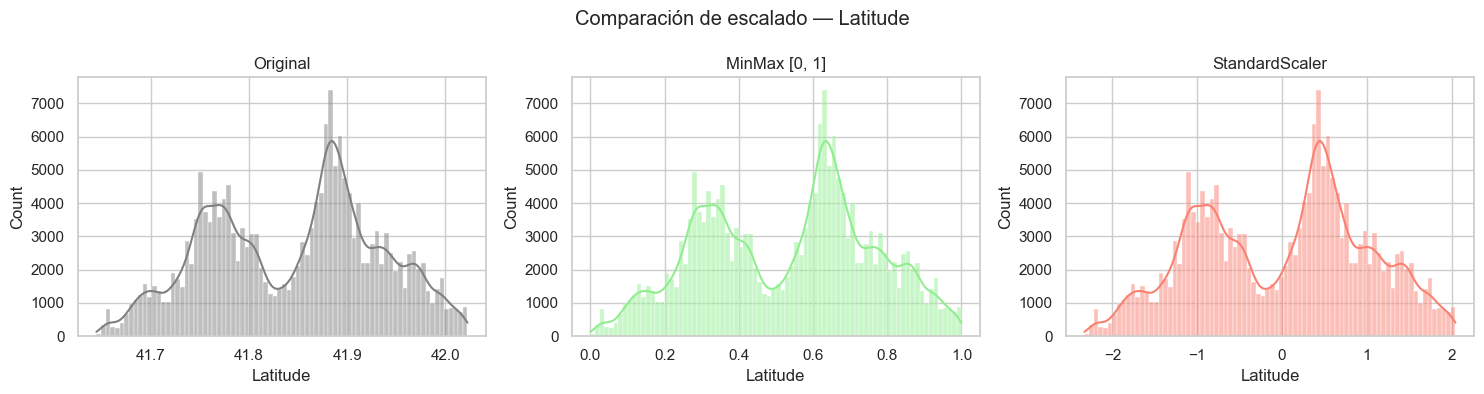

In [250]:
# Visualización comparativa sobre una variable representativa
col = 'Latitude'
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(X_train[col],      kde=True, ax=axes[0], color='gray');       axes[0].set_title('Original')
sns.histplot(X_train_mm[col],   kde=True, ax=axes[1], color='lightgreen'); axes[1].set_title('MinMax [0, 1]')
sns.histplot(X_train_std[col],  kde=True, ax=axes[2], color='salmon');     axes[2].set_title('StandardScaler')
plt.suptitle(f'Comparación de escalado — {col}')
plt.tight_layout()
plt.show()


---
## 9. Balance de clases

El target `Arrest` ronda el 16% positivo. Bajo este desbalance, un modelo trivial que prediga siempre `False` alcanzaría ~84% de accuracy, lo que torna esa métrica poco informativa y motiva aplicar un **mecanismo de balanceo**.

**Técnica elegida:** `SMOTE` sobre el train estandarizado. SMOTE genera ejemplos sintéticos interpolando entre observaciones minoritarias cercanas en el espacio de features — preserva la información de la clase mayoritaria y evita el colapso muestral del undersampling aleatorio. Como alternativa se muestra `RandomUnderSampler` para contraste visual.

> **Pitfalls clave.**
> 1. SMOTE **solo se aplica al train**, nunca al test (el test debe reflejar la distribución real).
> 2. SMOTE requiere features 100% numéricas → por eso va después del encoding y del escalado.

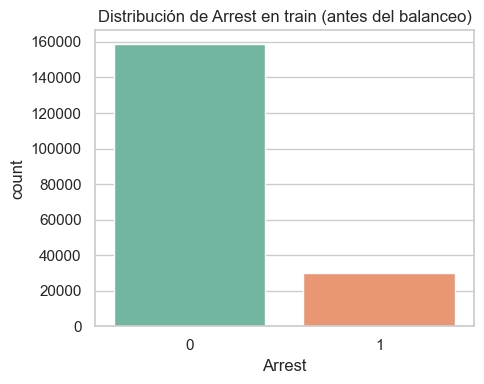

Arrest
0    0.8401
1    0.1599
Name: proportion, dtype: float64


In [251]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=y_train, hue=y_train, palette='Set2', ax=ax, legend=False)
ax.set_title('Distribución de Arrest en train (antes del balanceo)')
ax.set_xlabel('Arrest')
plt.tight_layout()
plt.show()

print(y_train.value_counts(normalize=True).round(4))


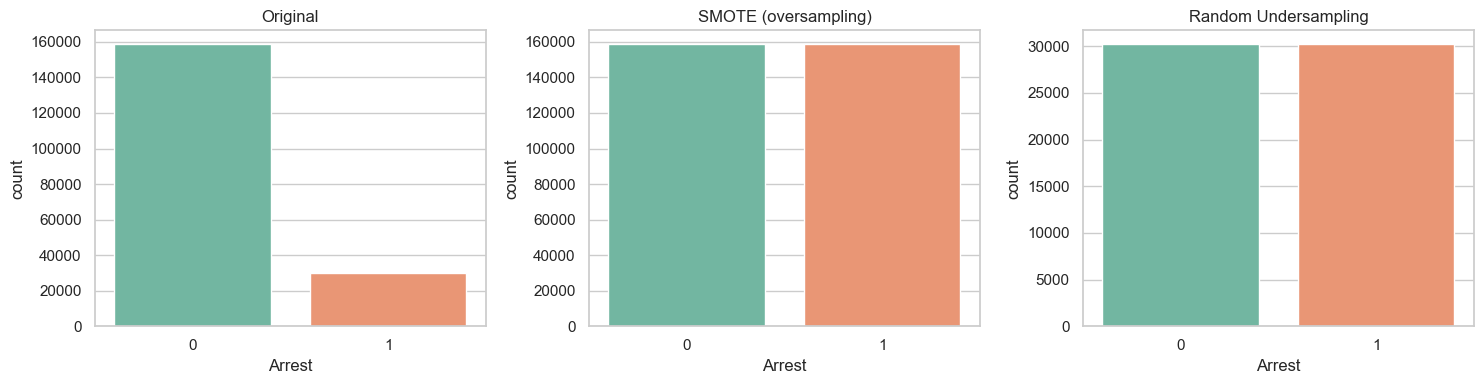

Antes  → {0: 158570, 1: 30184}
SMOTE  → {0: 158570, 1: 158570}
RUS    → {0: 30184, 1: 30184}


In [252]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_std, y_train)

# Referencia alternativa
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_us, y_train_us = rus.fit_resample(X_train_std, y_train)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x=y_train,     hue=y_train,     palette='Set2', ax=axes[0], legend=False)
sns.countplot(x=y_train_bal, hue=y_train_bal, palette='Set2', ax=axes[1], legend=False)
sns.countplot(x=y_train_us,  hue=y_train_us,  palette='Set2', ax=axes[2], legend=False)
axes[0].set_title('Original')
axes[1].set_title('SMOTE (oversampling)')
axes[2].set_title('Random Undersampling')
plt.tight_layout()
plt.show()

print(f'Antes  → {dict(y_train.value_counts())}')
print(f'SMOTE  → {dict(pd.Series(y_train_bal).value_counts())}')
print(f'RUS    → {dict(pd.Series(y_train_us).value_counts())}')


### 9.1 Ventajas y desventajas: SMOTE vs. RandomUnderSampler

**SMOTE (oversampling sintético) — elegido.**

*Ventajas:*
- Preserva **toda la información** de la clase mayoritaria (no descarta filas).
- Genera ejemplos minoritarios interpolados que suavizan la frontera de decisión.
- Apropiado cuando la clase minoritaria tiene pocos ejemplos absolutos.

*Desventajas:*
- Puede **inflar ejemplos irreales** si la clase minoritaria está muy dispersa (las interpolaciones entre clusters distantes caen en zonas "ficticias" del espacio).
- Aumenta el tamaño del train (× ~6 en este caso), encareciendo el entrenamiento.
- Requiere features **100 % numéricas y escaladas**: por eso se aplica después de §6 y §8.
- **Solo se aplica al train**, nunca al test — es fácil equivocarse y contaminar la evaluación.

**RandomUnderSampler (undersampling aleatorio) — alternativa.**

*Ventajas:*
- Reduce el tamaño del dataset → entrenamiento más rápido.
- No inventa datos (evita el riesgo de ejemplos sintéticos irreales de SMOTE).

*Desventajas:*
- **Descarta información** de la clase mayoritaria → puede degradar performance en datasets grandes.
- Muy sensible a la muestra descartada (alta varianza si se repite el experimento).

**Alternativa complementaria:** muchos clasificadores (`LogisticRegression`, `RandomForestClassifier`, `XGBClassifier`) aceptan `class_weight='balanced'` / `scale_pos_weight`, que pondera el costo de error sin alterar los datos. Es una tercera vía que conviene comparar en una etapa de modelado.

---
## 10. Selección de features (filtros)

Se evalúan tres filtros complementarios:

1. **Correlación entre features** (Pearson, Spearman, Kendall) para detectar redundancia.
2. **`VarianceThreshold`** para descartar features con varianza despreciable.
3. **`SelectKBest`** con tres estadísticos:
   - `chi2` (requiere features no negativos → usamos `X_train_mm`)
   - `f_classif` (ANOVA numérico vs. target categórico)
   - `mutual_info_classif` (captura no-linealidad)

Comparando los rankings de los tres podemos identificar features que son robustamente útiles en múltiples criterios.

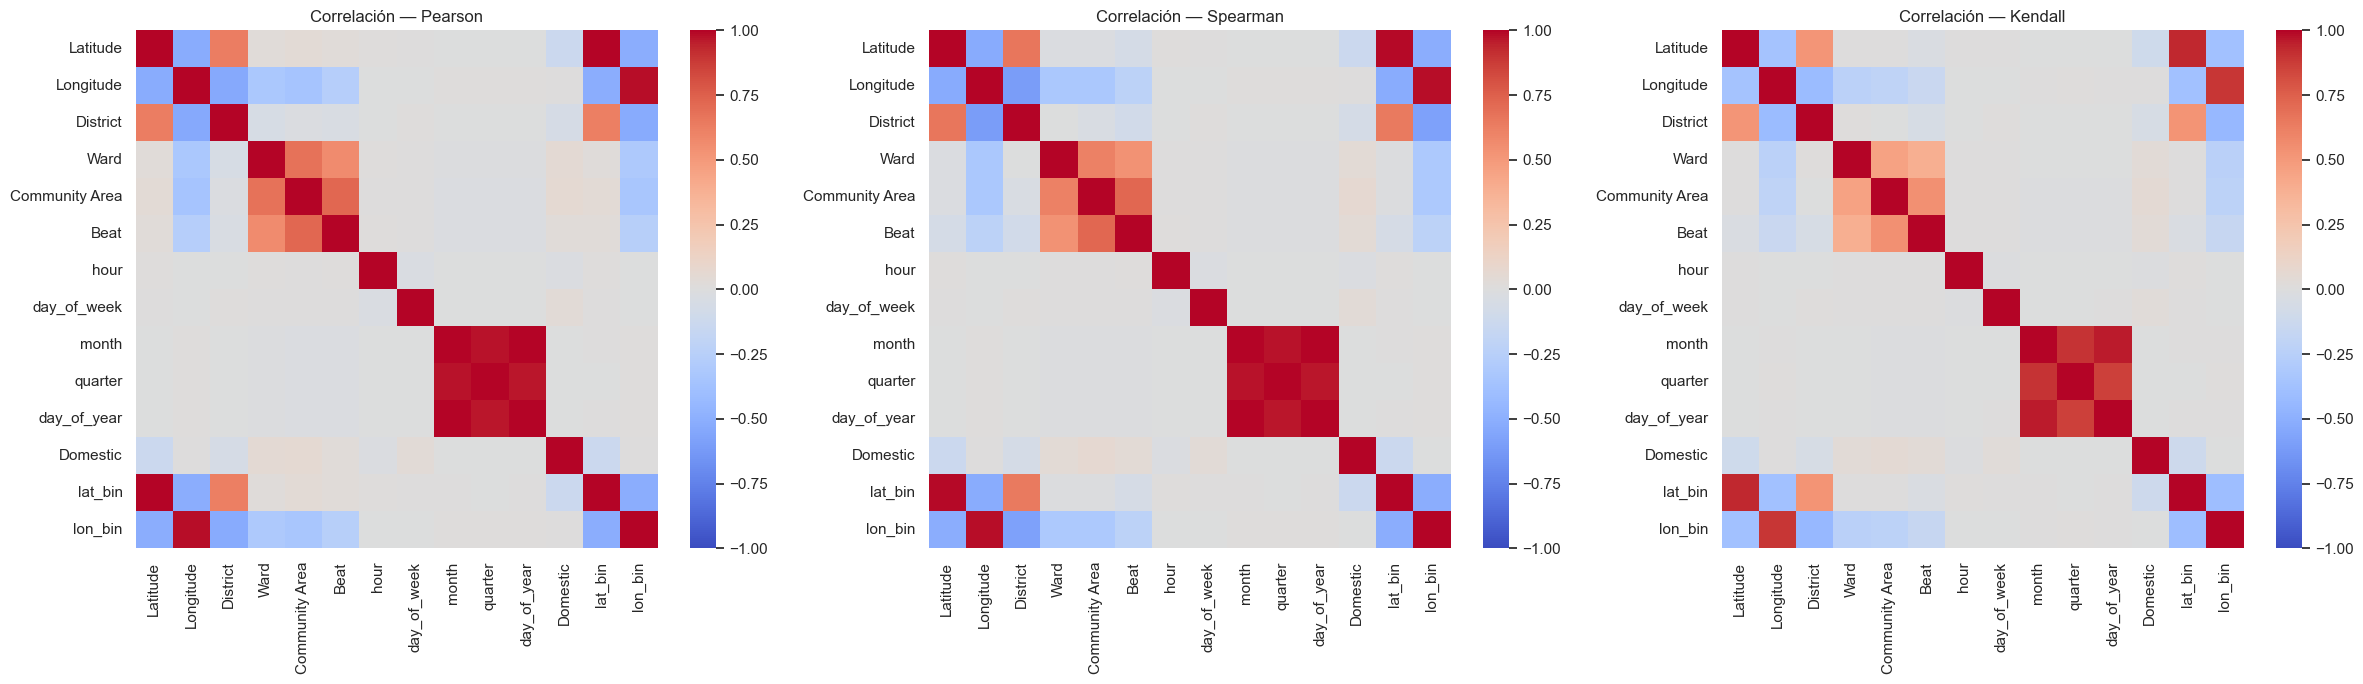

In [253]:
# Heatmap de correlaciones — muestreamos para que sea legible
sample_cols = [
    'Latitude', 'Longitude',
    'District', 'Ward', 'Community Area', 'Beat',
    'hour', 'day_of_week', 'month', 'quarter', 'day_of_year',
    'Domestic',
    'lat_bin', 'lon_bin',
]
sample_cols = [c for c in sample_cols if c in X_train_std.columns]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, method in zip(axes, ['pearson', 'spearman', 'kendall']):
    corr = X_train_std[sample_cols].corr(method=method)
    sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f'Correlación — {method.capitalize()}')
plt.tight_layout()
plt.show()


In [254]:
# Pares con |corr| alta (Pearson), como señal de redundancia
corr_p = X_train_std[sample_cols].corr().abs()
pairs = (
    corr_p.where(np.triu(np.ones(corr_p.shape, dtype=bool), k=1))
          .stack().sort_values(ascending=False)
)
pairs[pairs > 0.9].head(15)


month      day_of_year    0.996236
Latitude   lat_bin        0.992266
Longitude  lon_bin        0.981019
month      quarter        0.969287
quarter    day_of_year    0.965762
dtype: float64

In [255]:
# VarianceThreshold sobre X_train_std — eliminamos features (casi) constantes.
# Trabajamos únicamente con columnas numéricas.
num_cols_std = X_train_std.select_dtypes(include=[np.number]).columns.tolist()

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train_std[num_cols_std].fillna(0))

mantenidas_vt  = [c for c, keep in zip(num_cols_std, vt.get_support()) if keep]
descartadas_vt = [c for c, keep in zip(num_cols_std, vt.get_support()) if not keep]

# Aplicamos el filtro efectivamente a train y test
X_train_vt = X_train_std[mantenidas_vt].copy()
X_test_vt  = X_test_std[mantenidas_vt].copy()

print(f'Features antes: {len(num_cols_std)} | después de VarianceThreshold: {len(mantenidas_vt)}')
print(f'\n{len(descartadas_vt)} columnas con var < 0.01 (eliminadas):')
print(descartadas_vt[:20])
print(f'\nX_train_vt: {X_train_vt.shape} | X_test_vt: {X_test_vt.shape}')


Features antes: 70 | después de VarianceThreshold: 39

31 columnas con var < 0.01 (eliminadas):
['Primary Type_INTERFERENCE WITH PUBLIC OFFICER', 'Primary Type_SEX OFFENSE', 'Primary Type_OFFENSE INVOLVING CHILDREN', 'Primary Type_ARSON', 'Primary Type_CONCEALED CARRY LICENSE VIOLATION', 'Primary Type_HUMAN TRAFFICKING', 'Primary Type_CRIMINAL SEXUAL ASSAULT', 'Primary Type_PROSTITUTION', 'Primary Type_STALKING', 'Primary Type_INTIMIDATION', 'Primary Type_LIQUOR LAW VIOLATION', 'Primary Type_PUBLIC PEACE VIOLATION', 'Primary Type_HOMICIDE', 'Primary Type_KIDNAPPING', 'Primary Type_GAMBLING', 'Primary Type_OBSCENITY', 'Primary Type_OTHER NARCOTIC VIOLATION', 'Primary Type_PUBLIC INDECENCY', 'Primary Type_NON-CRIMINAL', 'FBI Code_24']

X_train_vt: (188754, 39) | X_test_vt: (47189, 39)


In [256]:
# SelectKBest — usamos las columnas ya filtradas por VarianceThreshold para no puntuar features cuasi-constantes.
X_tr_num_mm  = X_train_mm[mantenidas_vt].fillna(0)
X_tr_num_std = X_train_vt.fillna(0)

K = 20

sel_chi2  = SelectKBest(score_func=chi2,                k=K).fit(X_tr_num_mm,  y_train)
sel_anova = SelectKBest(score_func=f_classif,           k=K).fit(X_tr_num_std, y_train)
sel_mi    = SelectKBest(score_func=mutual_info_classif, k=K).fit(X_tr_num_std, y_train)

ranking = pd.DataFrame({
    'chi2':        pd.Series(sel_chi2.scores_,  index=X_tr_num_mm.columns),
    'f_classif':   pd.Series(sel_anova.scores_, index=X_tr_num_std.columns),
    'mutual_info': pd.Series(sel_mi.scores_,    index=X_tr_num_std.columns),
}).fillna(0)

# Ranking combinado: promediamos el rank (1 = mejor) de cada método.
top = (
    ranking.rank(ascending=False)
           .assign(rank_medio=lambda r: r.mean(axis=1))
           .sort_values('rank_medio').head(K)
)

# Features robustas: aparecen en el top-K del ranking combinado.
features_kbest = top.index.tolist()
print(f'Top-{K} features por ranking medio (chi2 + f_classif + mutual_info):')
display(top.round(2))

# APLICAMOS la selección efectivamente: generamos datasets filtrados.
X_train_kbest = X_train_vt[features_kbest].copy()
X_test_kbest  = X_test_vt[features_kbest].copy()
print(f'\nX_train_kbest: {X_train_kbest.shape} | X_test_kbest: {X_test_kbest.shape}')


Top-20 features por ranking medio (chi2 + f_classif + mutual_info):


,chi2,f_classif,mutual_info,rank_medio
Primary Type_NARCOTICS,1.0,1.0,2.0,1.33
FBI Code_18,2.0,2.0,1.0,1.67
FBI Code_15,3.0,3.0,5.0,3.67
Primary Type_WEAPONS VIOLATION,4.0,4.0,6.0,4.67
FBI Code_06,7.0,7.0,8.0,7.33
Primary Type_CRIMINAL DAMAGE,5.5,9.5,11.0,8.67
FBI Code_14,5.5,9.5,13.0,9.33
Beat,16.0,5.0,7.0,9.33
Primary Type_THEFT,10.0,11.0,9.0,10.00
Community Area,18.0,6.0,10.0,11.33



X_train_kbest: (188754, 20) | X_test_kbest: (47189, 20)


Los tres estadísticos miden cosas distintas (asociación χ², varianza explicada lineal, información mutua no-lineal). Un feature que aparece en los tres rankings es un candidato **robusto** para el modelo final — por eso promediamos los ranks y nos quedamos con el top-K.

### 10.1 Ventajas y desventajas: filtros (SelectKBest / VarianceThreshold) vs. PCA

**Filtros (`VarianceThreshold` + `SelectKBest`) — elegidos como selección principal.**

*Ventajas:*
- **Preservan la interpretabilidad**: las features conservadas son las originales (`Latitude`, `Beat`, etc.), lo cual facilita explicar las predicciones.
- Rápidos y escalables: no requieren entrenar el modelo final.
- `SelectKBest` es **supervisado** → tiene en cuenta `y_train`, a diferencia de PCA.
- Se pueden combinar múltiples criterios (χ², ANOVA, información mutua) para robustez.

*Desventajas:*
- Evalúan cada feature **en forma univariada**: no capturan interacciones (un feature débil individualmente podría ser predictivo en combinación).
- `VarianceThreshold` es ciego al target (una feature cuasi-constante pero perfectamente correlacionada con `y` sería descartada).
- `chi2` requiere features **no negativas** → exige un escalado específico (`MinMaxScaler`).
- Elegir `K` y el umbral de varianza es una decisión arbitraria que conviene validar con CV.

**PCA — explorado en §11 como alternativa / complemento.**

Ver §11.1 abajo: PCA es no supervisado, más agresivo en reducción de dimensión, pero pierde interpretabilidad.

**Decisión.** Para este problema conservamos **ambos outputs** (`X_train_kbest` y `X_train_pca`) como alternativas para evaluar en una etapa posterior de modelado, dado que el trade-off interpretabilidad vs. compacidad se resuelve mejor contra performance real del clasificador.

---
## 11. Extracción de features — PCA

**Requisitos y supuestos:**

- PCA es **no supervisado** → ignora `y`.
- Exige features numéricas **escaladas** (varianza comparable entre variables). Usamos `X_train_std` / `X_test_std`.
- Asume relaciones **lineales** entre variables; aporta poco si la estructura es muy no lineal.

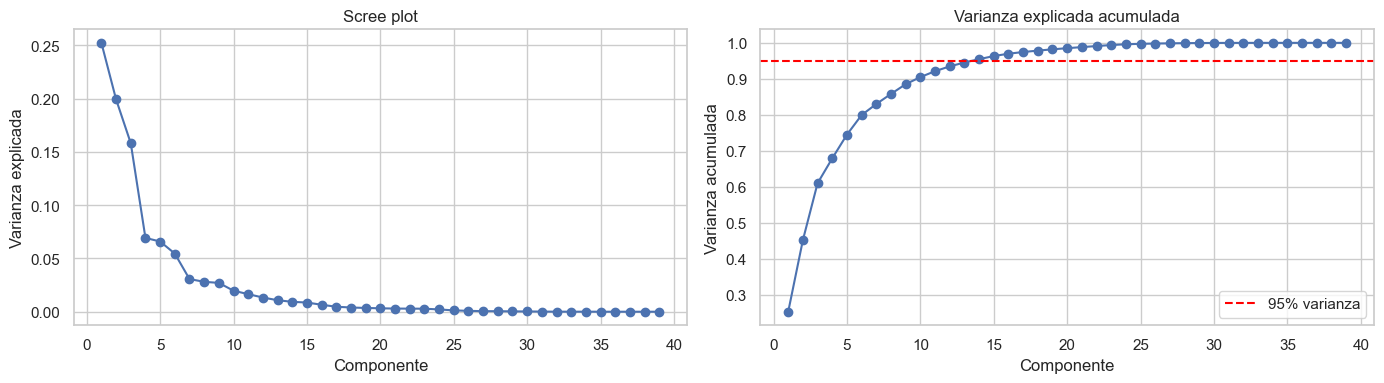

In [257]:
# Usamos el dataset ya filtrado por VarianceThreshold (evita componentes dominados por ruido de baja varianza).
X_tr_pca = X_train_vt.fillna(0)
X_te_pca = X_test_vt.fillna(0)
X_te_pca = X_te_pca[X_tr_pca.columns]

pca_full = PCA().fit(X_tr_pca)
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)
componentes = np.arange(1, len(exp_var) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(componentes, exp_var, marker='o')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Scree plot')
axes[0].grid(True)

axes[1].plot(componentes, cum_var, marker='o')
axes[1].axhline(0.95, color='red', linestyle='--', label='95% varianza')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Varianza acumulada')
axes[1].set_title('Varianza explicada acumulada')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()


In [258]:
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_tr_pca)
X_test_pca  = pca.transform(X_te_pca)

print(f'Componentes para retener 95% de varianza: {pca.n_components_}')
print(f'X_train_pca: {X_train_pca.shape} | X_test_pca: {X_test_pca.shape}')


Componentes para retener 95% de varianza: 14
X_train_pca: (188754, 14) | X_test_pca: (47189, 14)


In [259]:
# Loadings (cargas) de los primeros 5 componentes
loadings = pd.DataFrame(
    pca.components_[:5].T,
    columns=[f'PC{i+1}' for i in range(5)],
    index=X_tr_pca.columns,
)
# Top contribuciones por componente (en valor absoluto)
for c in loadings.columns:
    top5 = loadings[c].abs().sort_values(ascending=False).head(5).index
    print(f'\n{c} — top contribuciones:')
    print(loadings.loc[top5, c].round(3))



PC1 — top contribuciones:
Longitude   -0.456
lon_bin     -0.452
Latitude     0.408
lat_bin      0.406
District     0.356
Name: PC1, dtype: float64

PC2 — top contribuciones:
month          0.578
day_of_year    0.577
quarter        0.572
lat_bin        0.037
Latitude       0.037
Name: PC2, dtype: float64

PC3 — top contribuciones:
Community Area    0.515
Beat              0.492
Ward              0.485
lat_bin          -0.286
Latitude         -0.286
Name: PC3, dtype: float64

PC4 — top contribuciones:
hour          -0.718
day_of_week    0.691
lat_bin       -0.031
lon_bin       -0.030
Longitude     -0.030
Name: PC4, dtype: float64

PC5 — top contribuciones:
day_of_week   -0.722
hour          -0.688
lon_bin       -0.037
Longitude     -0.037
lat_bin       -0.028
Name: PC5, dtype: float64


### 11.1 Ventajas y desventajas de PCA

**Ventajas:**

- Reduce la dimensión conservando la mayor parte de la varianza del dataset.
- Descorrelaciona las features (los componentes son ortogonales), mitigando la multicolinealidad.
- Puede acelerar el entrenamiento en modelos sensibles a la dimensión.

**Desventajas:**

- Los componentes son combinaciones lineales de features originales → **pierde interpretabilidad**.
- Asume relaciones **lineales**; si la estructura del problema es fuertemente no lineal, PCA aporta poco.
- Es **sensible al escalado**: features no estandarizadas dominan la varianza.
- Es **no supervisado**: puede descartar información útil para predecir `Arrest` si esta información vive en direcciones de baja varianza.

---
## 12. Conclusiones y persistencia de artefactos

### Resumen de impacto dimensional

In [260]:
resumen = pd.DataFrame([
    ['1. Dataset enriquecido (post-merge)',     df_chicago.shape[1]],
    ['2. Tras limpieza general',                df_clean.shape[1] - 1],  # -1 por el target
    ['6. Tras codificación (OHE + TE)',         X_train.shape[1]],
    ['8. Tras escalado (std, solo numéricas)', len(num_cols_std)],
    ['9. Tras SMOTE (train balanceado)',        X_train_bal.shape[1]],
    ['10a. Tras VarianceThreshold',             X_train_vt.shape[1]],
    ['10b. Tras SelectKBest (top-K robustas)',  X_train_kbest.shape[1]],
    ['11. Tras PCA (95% varianza)',             pca.n_components_],
], columns=['Etapa', 'Nº features'])
resumen


,Etapa,Nº features
0,1. Dataset enriquecido (post-merge),26
1,2. Tras limpieza general,10
2,6. Tras codificación (OHE + TE),70
3,"8. Tras escalado (std, solo numéricas)",70
4,9. Tras SMOTE (train balanceado),70
5,10a. Tras VarianceThreshold,39
6,10b. Tras SelectKBest (top-K robustas),20
7,11. Tras PCA (95% varianza),14


### Discusión

- **Filtros vs. PCA.** Los filtros (`VarianceThreshold`, `SelectKBest`) preservan la interpretabilidad de las variables originales y son preferibles cuando se quiere explicar las predicciones. PCA reduce más agresivamente la dimensión pero sacrifica interpretabilidad, y al ser no supervisado puede descartar información útil para la clasificación. Mantenemos **ambos** (`X_train_kbest` y `X_train_pca`) como alternativas a comparar en una etapa posterior de modelado.
- **SMOTE vs. undersampling vs. `class_weight`.** Se optó por SMOTE porque genera ejemplos sintéticos de la clase minoritaria sin descartar información de la mayoritaria (ver §9.1). Las alternativas `RandomUnderSampler` y `class_weight='balanced'` (soportado nativamente por `LogisticRegression`, `RandomForestClassifier`) son caminos complementarios que conviene contrastar.
- **Features orientadas al target.** La información geográfica orientada al target se captura vía `TargetEncoder` aplicado sobre `Beat` / `Community Area` / `Ward` en §6, que estima la tasa de arresto por categoría con suavizado bayesiano.
- **Outliers.** No se detectan ni tratan outliers en este notebook: las únicas variables continuas (`Latitude`, `Longitude`) presentan valores extremos que son **zonas geográficas legítimas de Chicago** (según el EDA), y los códigos geográficos/categóricos no tienen noción de outlier. Aplicar winsorización distorsionaría la realidad espacial; eliminar filas sesgaría el análisis territorial.
- **Data leakage.** Todos los transformadores (`SimpleImputer`, `OneHotEncoder`, `TargetEncoder`, `StandardScaler`, `MinMaxScaler`, `KBinsDiscretizer`, `VarianceThreshold`, `SelectKBest`, `PCA`) fueron ajustados **solo sobre `X_train`** y aplicados al test sin reajustarlos. SMOTE se aplicó únicamente al train.

### Persistencia

Guardamos los datasets preprocesados para usarlos en trabajos posteriores.

In [261]:
from pathlib import Path
out_dir = Path('processed')
out_dir.mkdir(exist_ok=True)

# Usamos pickle (robusto a extension dtypes y sin dependencias extra)
def _dedup(cols):
    seen, out = {}, []
    for c in cols:
        if c in seen:
            seen[c] += 1
            out.append(f'{c}__{seen[c]}')
        else:
            seen[c] = 0
            out.append(c)
    return out

# Train balanceado (SMOTE) sobre TODAS las features escaladas
cols_bal = _dedup(list(X_train_std.columns))
pd.DataFrame(X_train_bal, columns=cols_bal).to_pickle(out_dir / 'X_train_bal.pkl')
pd.Series(y_train_bal, name='Arrest').to_pickle(out_dir / 'y_train_bal.pkl')

# Test estandarizado de referencia
X_test_std.to_pickle(out_dir / 'X_test_std.pkl')
y_test.to_pickle(out_dir / 'y_test.pkl')

# Train/test tras VarianceThreshold (features originales, solo numéricas, no-constantes)
X_train_vt.to_pickle(out_dir / 'X_train_vt.pkl')
X_test_vt.to_pickle(out_dir / 'X_test_vt.pkl')

# Train/test tras SelectKBest (top-K features robustas)
X_train_kbest.to_pickle(out_dir / 'X_train_kbest.pkl')
X_test_kbest.to_pickle(out_dir / 'X_test_kbest.pkl')

# Versión PCA (95% varianza)
pc_cols = [f'PC{i+1}' for i in range(pca.n_components_)]
pd.DataFrame(X_train_pca, columns=pc_cols).to_pickle(out_dir / 'X_train_pca.pkl')
pd.DataFrame(X_test_pca,  columns=pc_cols).to_pickle(out_dir / 'X_test_pca.pkl')

# y_train original (sin balanceo) — útil como referencia
y_train.to_pickle(out_dir / 'y_train.pkl')

print(f'Archivos guardados en {out_dir.resolve()}')
for p in sorted(out_dir.iterdir()):
    print(' -', p.name)


Archivos guardados en /Users/francomorero/PycharmProjects/franco/ceia-analisis-de-datos-tp-final/processed
 - X_test_kbest.pkl
 - X_test_pca.pkl
 - X_test_std.pkl
 - X_test_vt.pkl
 - X_train_bal.pkl
 - X_train_kbest.pkl
 - X_train_pca.pkl
 - X_train_vt.pkl
 - figures
 - y_test.pkl
 - y_train.pkl
 - y_train_bal.pkl


### Checklist contra la consigna

| Requerimiento | Sección |
|---|---|
| Limpieza general del dataset | §2 |
| Split train / test estratificado | §3 |
| Valores faltantes (MCAR/MAR/MNAR) | §4 |
| Creación de nuevos features (justificados) | §5 |
| Codificación (OHE, TargetEncoder, cíclico) | §6 |
| Discretización | §7 |
| Escalado / normalización | §8 |
| Balance / desbalance de clases + justificación de técnica | §9, §9.1 |
| Selección de features (filtros) + ventajas/desventajas | §10, §10.1 |
| Extracción de features (PCA) + ventajas/desventajas | §11, §11.1 |
| Resumen de impacto dimensional | §12 |
| Persistencia de artefactos reproducibles | §12 |
